# QProfiler CC/CQ/QC/QQ 2×2 on CD4-vs-CD8 — classical vs quantum embeddings × classical vs quantum ML

The full 2×2 quadrant benchmark on the one discriminative single-cell binary task,
CD4 vs CD8 T cells. The two axes are:

- Embedding type — Classical (`pca, nmf, umap, isomap, lle` + the classical-walk
  ablation `quvine_rwr`, plus `node2vec, graphsage, baseline_filter_*`) vs Quantum
  (QuVINE quantum-walk embeddings `quvine_ctqw, quvine_dtqw` and the quantum-calibrated
  diffusion filters `filter_ctqw_heat, filter_dtqw_heat`).
- ML-method type — Classical (`lr, svc, rf, mlp, nb, dt, xgb`) vs Quantum
  (`pqk, qsvc, vqc, qnn`).

That gives four quadrants:

| | Classical ML | Quantum ML |
|---|---|---|
| **Classical embedding** | **CC** | **CQ** |
| **Quantum embedding** | **QC** | **QQ** |

QProfiler already benchmarks the full `embeddings × model` cross-product, so the entire 2×2
falls out of one config run — we just tag each result row by quadrant afterward.

QuVINE embeddings are wired into QProfiler's `get_embeddings` by name (any `quvine_*` /
`node2vec` / `graphsage` / `filter_*` method). QuVINE is transductive: it embeds every node
of a graph at once. We build one kNN cell graph over the concatenated train+test features,
embed all cells once, then slice the rows back into train/test by construction order. Only
feature-derived structure enters the graph — the class label never does — so this is the
standard transductive protocol (the same all-cells-at-once embedding the QuVINE tutorial
uses), **not label leakage**.

> Dropped on purpose: the `gat_*` / `graphgps_*` walk families. Their walk variant is
> compressed into a single calibrated heat-time scalar `t`, which collapses the
> ctqw/dtqw/rwr distinction — so they add cost without a real quantum-walk signal here. The
> cheaper `filter_*` diffusion arm is kept as the quantum-calibrated representative (with the
> caveat that `filter_ctqw` vs `filter_dtqw` may still converge for the same reason).

---

**Install.** QuVINE ships behind an optional extra, so a plain `pip install qbiocode`
does *not* pull its dependencies (gensim, hiperwalk, node2vec, torch-geometric,
python-louvain, ripser, omegaconf). Install it with:

```bash
pip install "qbiocode[quvine]"
```

Calling a `quvine_*` method without the extra raises an error naming the missing
package and this exact command, rather than a bare `ModuleNotFoundError`.

This notebook also reads an `.h5ad` fixture, so it needs `anndata` — part of the
base install.


## 1. Setup and imports

In [ ]:
import os
import sys
import shutil
import glob
import yaml
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import qbiocode as qbc
from qbiocode.apps.qprofiler import qprofiler as profiler
from qbiocode.utils import tutorial_data_path

sns.set_style("whitegrid")

# ---- Paths ----
# The cd4_vs_cd8 fixture is committed once and shared with the QProfiler and QuVINE
# tutorials; tutorial_data_path() finds it in whichever tree holds it (it searches
# $QBC_DATA first, then every fixture directory of a source checkout) and raises a
# FileNotFoundError naming each directory tried. export_task_csv() below wants the
# containing directory, not the file.
H5AD_DIR = os.path.dirname(tutorial_data_path("pbmc5k_small_cd4_vs_cd8.h5ad"))
NB_DIR = os.getcwd()   # this notebook's own directory (portable across docs/ and tutorial/)
DATA_DIR = os.path.join(NB_DIR, "data", "sc_binary")             # per-task CSVs written here
# The config template ships as package data, so read it out of the installed package
# rather than deriving a repo root from qbc.__file__ -- that only resolves for an
# editable install and silently points into site-packages for a normal one.
CONFIG_TEMPLATE = os.path.join(
    os.path.dirname(os.path.abspath(profiler.__file__)), "configs", "config.yaml")
OUT_DIR = NB_DIR                                                  # ModelResults.csv etc. land here

os.makedirs(DATA_DIR, exist_ok=True)
# QProfiler writes outputs to the current working directory -> pin it to OUT_DIR.
os.chdir(OUT_DIR)
print("qbiocode", qbc.__version__)
print("cwd (outputs):", os.getcwd())

## 2. Configuration — the four axes + a `FULL_GRID` toggle

The canonical Classical (C) and Quantum (Q) method lists for each axis are fixed
below — they define which quadrant every result lands in. `FULL_GRID` chooses how much of
each axis actually runs:

- `FULL_GRID = False` (default): a tractable subset — a couple of embeddings and models
  per axis, with `pqk` as the sole quantum ML. Still covers all four quadrants, runs on a
  laptop in minutes.
- `FULL_GRID = True`: every embedding × every model — much slower, since quantum ML on the
  local statevector simulator dominates the runtime (14 embeddings × 11 models ×
  `ITER` splits).

In [2]:
# ============================ EXPERIMENT CONFIG ============================
TASK = "cd4_vs_cd8"   # the only discriminative task (others saturate at ~1.0)
LEAKAGE_SAFE = True   # drop label-defining marker genes
N_FEATURES = 50       # top-variance HVGs exported (keeps compute light)
N_COMPONENTS = 8      # embedding width == qubit count for PQK/quantum encoders
ITER = 3              # train/test splits per (embedding, model)
TEST_SIZE = 0.3

# ---- Canonical axis definitions (these decide the quadrant of every arm) ----
# Classical embeddings: sklearn reductions + graph embeddings whose walk is classical.
# quvine_rwr is the classical random-walk ABLATION of the quantum walks (same pipeline).
C_EMB = ["pca", "nmf", "umap", "isomap", "lle",
         "quvine_rwr", "node2vec", "graphsage",
         "baseline_filter_heat", "baseline_filter_poly"]
# Quantum embeddings: QuVINE quantum-walk SGNS + quantum-calibrated diffusion filters.
Q_EMB = ["quvine_ctqw", "quvine_dtqw", "filter_ctqw_heat", "filter_dtqw_heat"]

C_ML = ["lr", "svc", "rf", "mlp", "nb", "dt", "xgb"]   # classical models
Q_ML = ["pqk", "qsvc", "vqc", "qnn"]                    # quantum models

# ---- What actually runs ----
FULL_GRID = False
if FULL_GRID:
    EMB = C_EMB + Q_EMB
    ML  = C_ML + Q_ML
else:
    # One+ representative per family so all four quadrants are populated but cheap.
    EMB = ["pca", "quvine_rwr",          # classical embeddings (incl. classical-walk ablation)
           "quvine_ctqw", "quvine_dtqw"]  # quantum-walk embeddings
    ML  = ["lr", "rf",                    # classical ML
           "pqk"]                         # quantum ML (statevector sim; the slow arm)

# PQK feature-map tuning: a SHALLOW linearly-entangled ZZ map (reps=1) avoids the
# quantum-kernel concentration the deep template default suffers -- higher accuracy, ~3x faster.
PQK_ARGS = {"encoding": "ZZ", "entanglement": "linear", "primitive": "estimator", "reps": 1}

# QuVINE overrides forwarded to embed(). `dimension` is forced to N_COMPONENTS automatically.
# steps is kept small: quantum walks spread ballistically, so large step counts over-mix and
# wash out same-class structure.
QUVINE_ARGS = {"walks": {"steps": 4, "num_walks": 10, "walk_length": 10},
               "train": {"epochs": 50},
               "views": {"num_views": 4}}
N_NEIGHBORS = 15   # neighbors for the kNN cell graph QuVINE embeds on
# ===========================================================================

Q_EMB_SET, Q_ML_SET = set(Q_EMB), set(Q_ML)
def quadrant(emb, model):
    return ("Q" if emb in Q_EMB_SET else "C") + ("Q" if model in Q_ML_SET else "C")

print("FULL_GRID:", FULL_GRID)
print("embeddings:", EMB)
print("models     :", ML)
print("quadrants that will appear:",
      sorted({quadrant(e, m) for e in EMB for m in ML}))
print(f"n_components={N_COMPONENTS} | iters={ITER} | combos={len(EMB)*len(ML)}")

FULL_GRID: False
embeddings: ['pca', 'quvine_rwr', 'quvine_ctqw', 'quvine_dtqw']
models     : ['lr', 'rf', 'pqk']
quadrants that will appear: ['CC', 'CQ', 'QC', 'QQ']
n_components=8 | iters=3 | combos=12


## 3. Build the CD4-vs-CD8 CSV

QProfiler reads plain CSVs (features in columns, **label in the last column**). We export the
CD4-vs-CD8 task from the small balanced h5ad (500 cells, 250/class), keeping the top
`N_FEATURES` high-variance HVGs and dropping the label-defining markers when `LEAKAGE_SAFE`.
This is the same leakage-safe export used by the `sc_binary_qprofiler.ipynb` tutorial.

In [3]:
def export_task_csv(task, n_features, leakage_safe, data_dir, h5ad_dir):
    """Write pbmc-<task>.csv (top-variance HVGs + label) and return (path, info)."""
    adata = ad.read_h5ad(os.path.join(h5ad_dir, f"pbmc5k_small_{task}.h5ad"))

    keep = adata.var["highly_variable"].to_numpy().copy()
    if leakage_safe and "is_label_leakage" in adata.var:
        keep &= ~adata.var["is_label_leakage"].to_numpy()

    X = adata[:, keep].X
    X = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
    genes = adata.var_names[keep].to_numpy()

    order = np.argsort(X.var(axis=0))[::-1][:n_features]
    X_sel, genes_sel = X[:, order], genes[order]

    df = pd.DataFrame(X_sel, columns=list(genes_sel))
    df["label"] = adata.obs["label"].astype(str).to_numpy()   # label MUST be last column

    path = os.path.join(data_dir, f"pbmc-{task}.csv")
    df.to_csv(path, index=False)
    info = {"task": task, "n_cells": df.shape[0], "n_features": len(genes_sel),
            "classes": df["label"].value_counts().to_dict()}
    return path, info

csv_path, info = export_task_csv(TASK, N_FEATURES, LEAKAGE_SAFE, DATA_DIR, H5AD_DIR)
print(info)
print("CSV ->", csv_path)

{'task': 'cd4_vs_cd8', 'n_cells': 500, 'n_features': 50, 'classes': {'CD4_T': 250, 'CD8_T': 250}}
CSV -> /Users/aritrabose/Documents/ISMB26/internal/QBioCode/docs/source/tutorials/QProfiler/data/sc_binary/pbmc-cd4_vs_cd8.csv


## 4. Assemble the QProfiler config

Start from the shipped template (so every model-arg block is present) and override our
choices. `embeddings = EMB` and `model = ML` make QProfiler run the full cross-product;
`quvine_args` / `n_neighbors` are threaded through to the QuVINE embeddings.

In [4]:
config = yaml.safe_load(open(CONFIG_TEMPLATE))

config.update({
    "folder_path": os.path.abspath(DATA_DIR),
    "file_dataset": [f"pbmc-{TASK}.csv"],
    "embeddings": EMB,
    "model": ML,
    "n_components": N_COMPONENTS,
    "n_neighbors": N_NEIGHBORS,
    "iter": ITER,
    "test_size": TEST_SIZE,
    "stratify": ["y"],
    "scaling": ["True"],
    "n_jobs": 1,
    "grid_search": False,
    "backend": "simulator",   # only used by the quantum models
})
config["pqk_args"] = PQK_ARGS
config["quvine_args"] = QUVINE_ARGS

print("file_dataset:", config["file_dataset"])
print("embeddings  :", config["embeddings"])
print("models      :", config["model"])
print("pqk_args    :", config["pqk_args"])
print("quvine_args :", config["quvine_args"])

file_dataset: ['pbmc-cd4_vs_cd8.csv']
embeddings  : ['pca', 'quvine_rwr', 'quvine_ctqw', 'quvine_dtqw']
models      : ['lr', 'rf', 'pqk']
pqk_args    : {'encoding': 'ZZ', 'entanglement': 'linear', 'primitive': 'estimator', 'reps': 1}
quvine_args : {'walks': {'steps': 4, 'num_walks': 10, 'walk_length': 10}, 'train': {'epochs': 50}, 'views': {'num_views': 4}}


## 5. Run QProfiler

QProfiler appends to `ModelResults.csv`, `RawDataEvaluation.csv`, and `results.pkl` in the
working directory, so we clear stale outputs first. PQK caches its projections keyed by
dataset/embedding/iter — **not** by `pqk_args` — so we purge `pqk_projections/` too, otherwise
a stale cache would silently mask a feature-map change.

> With `FULL_GRID = True` this cell can run for a long time (quantum ML on the simulator).
> Start with the default subset to sanity-check the pipeline.

In [5]:
for f in ["ModelResults.csv", "RawDataEvaluation.csv", "results.pkl"]:
    if os.path.exists(f):
        os.remove(f)
shutil.rmtree("pqk_projections", ignore_errors=True)

profiler.main(config)

model_results = pd.read_csv("ModelResults.csv")
model_results["quadrant"] = [quadrant(e, m) for e, m
                             in zip(model_results["embeddings"], model_results["model"])]
print("ModelResults:", model_results.shape)
print("quadrants present:", sorted(model_results["quadrant"].unique()))
model_results[["embeddings", "model", "quadrant", "iteration",
               "accuracy", "f1_score", "auc"]].head(12)

Processing file: pbmc-cd4_vs_cd8.csv


at datapoint 0


at datapoint 100


at datapoint 200


at datapoint 300


...

at datapoint 300


at datapoint 0


at datapoint 100


ModelResults: (36, 33)
quadrants present: ['CC', 'CQ', 'QC', 'QQ']


,embeddings,model,quadrant,iteration,accuracy,f1_score,auc
0,pca,lr,CC,1,0.893333,0.892646,0.893333
1,pca,pqk,CQ,1,0.900000,0.899960,0.900000
2,pca,rf,CC,1,0.886667,0.886257,0.886667
3,quvine_rwr,lr,CC,1,0.846667,0.845506,0.846667
4,quvine_rwr,pqk,CQ,1,0.840000,0.839744,0.840000
5,quvine_rwr,rf,CC,1,0.886667,0.886054,0.886667
6,quvine_ctqw,lr,QC,1,0.860000,0.859694,0.860000
7,quvine_ctqw,pqk,QQ,1,0.813333,0.811693,0.813333
8,quvine_ctqw,rf,QC,1,0.893333,0.892857,0.893333
9,quvine_dtqw,lr,QC,1,0.853333,0.852915,0.853333


## 6. The 2×2 quadrant summary

Collapse every arm into its quadrant and report the **median** and **best** performance per
quadrant across all arms and splits. This is the headline CC/CQ/QC/QQ comparison: does a
quantum embedding (QC/QQ) or a quantum ML method (CQ/QQ) buy anything over the fully
classical CC corner on this hard task?

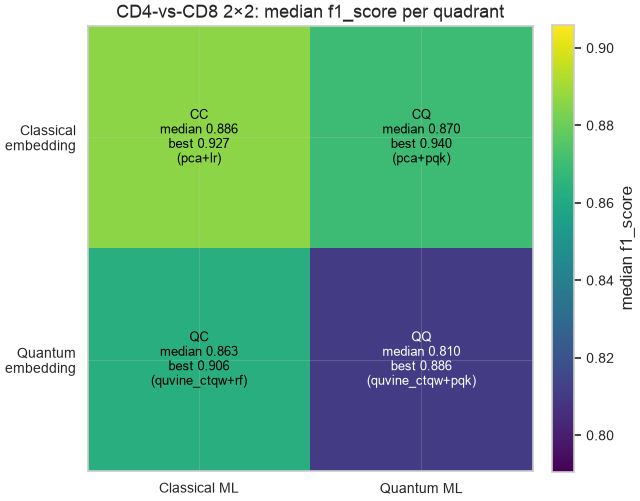

,median,best
quadrant,,
CC,0.886,0.927
CQ,0.870,0.940
QC,0.863,0.906
QQ,0.810,0.886


In [6]:
METRIC = "f1_score"   # switch to 'accuracy' or 'auc' if preferred

# Median & best (over arms and splits) per quadrant.
med = model_results.groupby("quadrant")[METRIC].median()
best = model_results.groupby("quadrant")[METRIC].max()
# Best arm (embedding+model) per quadrant, by median over splits.
arm_med = (model_results.groupby(["quadrant", "embeddings", "model"])[METRIC]
           .median().reset_index())
best_arm = arm_med.loc[arm_med.groupby("quadrant")[METRIC].idxmax()]
best_arm = best_arm.set_index("quadrant")

order = ["CC", "CQ", "QC", "QQ"]
grid_med  = np.array([[med.get("CC", np.nan), med.get("CQ", np.nan)],
                      [med.get("QC", np.nan), med.get("QQ", np.nan)]])
grid_best = np.array([[best.get("CC", np.nan), best.get("CQ", np.nan)],
                      [best.get("QC", np.nan), best.get("QQ", np.nan)]])

fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(grid_med, cmap="viridis", vmin=np.nanmin(grid_med) - 0.02,
               vmax=np.nanmax(grid_med) + 0.02)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Classical ML", "Quantum ML"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Classical\nembedding", "Quantum\nembedding"])
for (i, j), q in zip([(0,0),(0,1),(1,0),(1,1)], order):
    if q not in med.index:
        ax.text(j, i, f"{q}\n(not run)", ha="center", va="center", color="white")
        continue
    ba = best_arm.loc[q]
    ax.text(j, i,
            f"{q}\nmedian {grid_med[i,j]:.3f}\nbest {grid_best[i,j]:.3f}\n"
            f"({ba['embeddings']}+{ba['model']})",
            ha="center", va="center", fontsize=9,
            color="white" if grid_med[i,j] < np.nanmean(grid_med) else "black")
ax.set_title(f"CD4-vs-CD8 2×2: median {METRIC} per quadrant")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=f"median {METRIC}")
plt.tight_layout(); plt.show()

pd.DataFrame({"median": med, "best": best}).reindex(order).round(3)

## 7. Per-arm heatmap (embedding × model), quadrants outlined

The full resolution behind the 2×2: median `f1_score` for every (embedding, model) arm. Rows
are grouped classical-then-quantum embeddings; columns classical-then-quantum models. The
dashed lines mark the CC/CQ/QC/QQ boundaries.

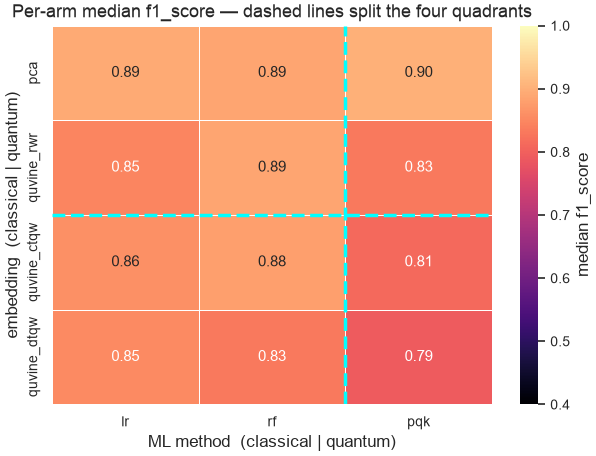

In [7]:
pivot = (model_results.groupby(["embeddings", "model"])[METRIC].median().unstack("model"))

# Order rows/cols classical-first, then quantum; keep only what ran.
row_order = [e for e in C_EMB + Q_EMB if e in pivot.index]
col_order = [m for m in C_ML + Q_ML if m in pivot.columns]
pivot = pivot.loc[row_order, col_order]

n_c_emb = sum(e in set(C_EMB) for e in row_order)   # classical-embedding row count
n_c_ml  = sum(m in set(C_ML) for m in col_order)    # classical-ML column count

fig, ax = plt.subplots(figsize=(1.1 * len(col_order) + 3, 0.7 * len(row_order) + 2))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="magma", vmin=0.4, vmax=1.0,
            cbar_kws={"label": f"median {METRIC}"}, ax=ax, linewidths=0.5)
# Quadrant boundaries.
if 0 < n_c_ml < len(col_order):
    ax.axvline(n_c_ml, color="cyan", lw=2.5, ls="--")
if 0 < n_c_emb < len(row_order):
    ax.axhline(n_c_emb, color="cyan", lw=2.5, ls="--")
ax.set_xlabel("ML method  (classical | quantum)")
ax.set_ylabel("embedding  (classical | quantum)")
ax.set_title(f"Per-arm median {METRIC} — dashed lines split the four quadrants")
plt.tight_layout(); plt.show()

## 8. Distribution per quadrant + the classical-walk ablation

Boxplots of every arm's per-split metric within each quadrant show spread, not just the
median. Alongside, we isolate the **`quvine_rwr` vs `quvine_ctqw` / `quvine_dtqw`** contrast:
same graph, same SGNS pipeline, same `dimension` — the *only* difference is a classical random
walk vs a quantum walk. That is the cleanest read on whether the quantum walk itself adds
discriminative structure (paired against the identical classical-walk baseline).

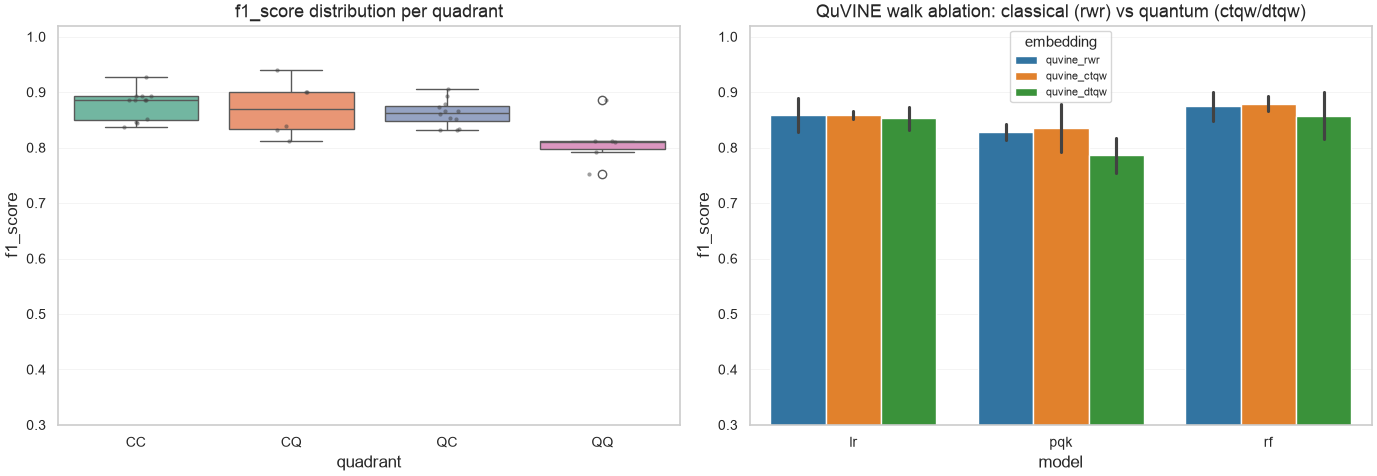

accuracy  f1_score    auc
embeddings  model                           
quvine_ctqw lr        0.860     0.860  0.860
            pqk       0.813     0.812  0.813
            rf        0.880     0.879  0.880
quvine_dtqw lr        0.853     0.853  0.853
            pqk       0.793     0.793  0.793
            rf        0.833     0.833  0.833
quvine_rwr  lr        0.847     0.846  0.847
            pqk       0.833     0.832  0.833
            rf        0.887     0.886  0.887

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) metric distribution per quadrant
present = [q for q in order if q in model_results["quadrant"].unique()]
sns.boxplot(data=model_results, x="quadrant", y=METRIC, order=present, ax=axes[0],
            palette="Set2")
sns.stripplot(data=model_results, x="quadrant", y=METRIC, order=present, ax=axes[0],
              color=".25", size=3, alpha=0.5)
axes[0].set_title(f"{METRIC} distribution per quadrant")
axes[0].set_ylim(0.3, 1.02)

# (b) classical-walk ablation: quvine_rwr vs quantum walks, per ML model
walk_emb = [e for e in ["quvine_rwr", "quvine_ctqw", "quvine_dtqw"]
            if e in model_results["embeddings"].unique()]
abl = model_results[model_results["embeddings"].isin(walk_emb)]
if len(walk_emb) >= 2 and not abl.empty:
    sns.barplot(data=abl, x="model", y=METRIC, hue="embeddings",
                hue_order=walk_emb, ax=axes[1], errorbar="sd")
    axes[1].set_title("QuVINE walk ablation: classical (rwr) vs quantum (ctqw/dtqw)")
    axes[1].set_ylim(0.3, 1.02)
    axes[1].legend(title="embedding", fontsize=8)
else:
    axes[1].text(0.5, 0.5, "need >=2 of quvine_rwr/ctqw/dtqw\n(enable them in the config)",
                 ha="center", va="center")
    axes[1].set_axis_off()
plt.tight_layout(); plt.show()

# Numeric ablation table (median over splits), if available.
if len(walk_emb) >= 2 and not abl.empty:
    display(abl.groupby(["embeddings", "model"])[["accuracy", "f1_score", "auc"]]
            .median().round(3))

## 9. Notes and caveats

- **The 2×2 is one cross-product run.** QProfiler benchmarks `embeddings × model`; tagging
  each row by (embedding∈Q_EMB, model∈Q_ML) recovers CC/CQ/QC/QQ. Add/remove arms by editing
  the axis lists in §2 — quadrant assignment follows automatically.
- **`quvine_rwr` is the classical-walk ablation**, deliberately placed in the *classical*
  embedding column: it shares the QuVINE SGNS pipeline with `quvine_ctqw`/`quvine_dtqw` but
  uses a classical random walk, so the QC/QQ-vs-CC gap it leaves is the honest quantum-walk
  effect (not a pipeline artifact).
- **`filter_ctqw_heat` vs `filter_dtqw_heat` may converge.** Both compress their walk into a
  single calibrated heat-time scalar, so the ctqw/dtqw distinction can wash out — expected,
  and the reason the `gat_*`/`graphgps_*` families were dropped entirely.
- **Transductive graph spans train+test features** — disclosed above; only feature structure,
  never the label, enters the embedding.
- **Compute:** quantum ML on the statevector simulator dominates. Keep `N_COMPONENTS` small
  (= qubit count) and use the default subset before `FULL_GRID = True`. Purge `pqk_projections/`
  between runs (done in §5) since the cache is not keyed by `pqk_args`.